<div style="background: #d9004c; 
            padding: 25px; 
            border-radius: 15px; 
            text-align: center;
            box-shadow: 3px 3px 15px rgba(0,0,0,0.2);">
    <h1 style="font-family: 'Arial Black', sans-serif; color: white; margin-bottom: 10px;">
        Digital Image Processing
    </h1>
        <h3 style="font-family: 'Arial Black', sans-serif; color: white; margin-bottom: 10px;">
        Topic: Ideal Low Pass Filter
    </h3>
        <h3 style="font-family: 'Arial Black', sans-serif; color: white; margin-bottom: 10px;">
        Notebook by - Himel Sarder
    </h3>
    <p style="font-family: 'Verdana', sans-serif; color: #ffffffcc; font-size: 16px; text-align: center">
        info.himelcse@gmail.com
    </p>
</div>

# Ideal Low Pass Filter
## An Ideal Low Pass Filter (ILPF) is a frequency domain filter used in Digital Image Processing to remove high-frequency components from an image while keeping low-frequency components.

## - Low frequencies → smooth areas, overall brightness
## - High frequencies → edges, noise, fine details

## So, ILPF is mainly used for image smoothing or blurring.

# Idea Behind ILPF
## The filter passes all frequencies below a cutoff value and blocks all frequencies above it.
## That means:
## - Frequencies inside a radius 𝐷0 → kept
## - Frequencies outside the radius 𝐷0 → removed

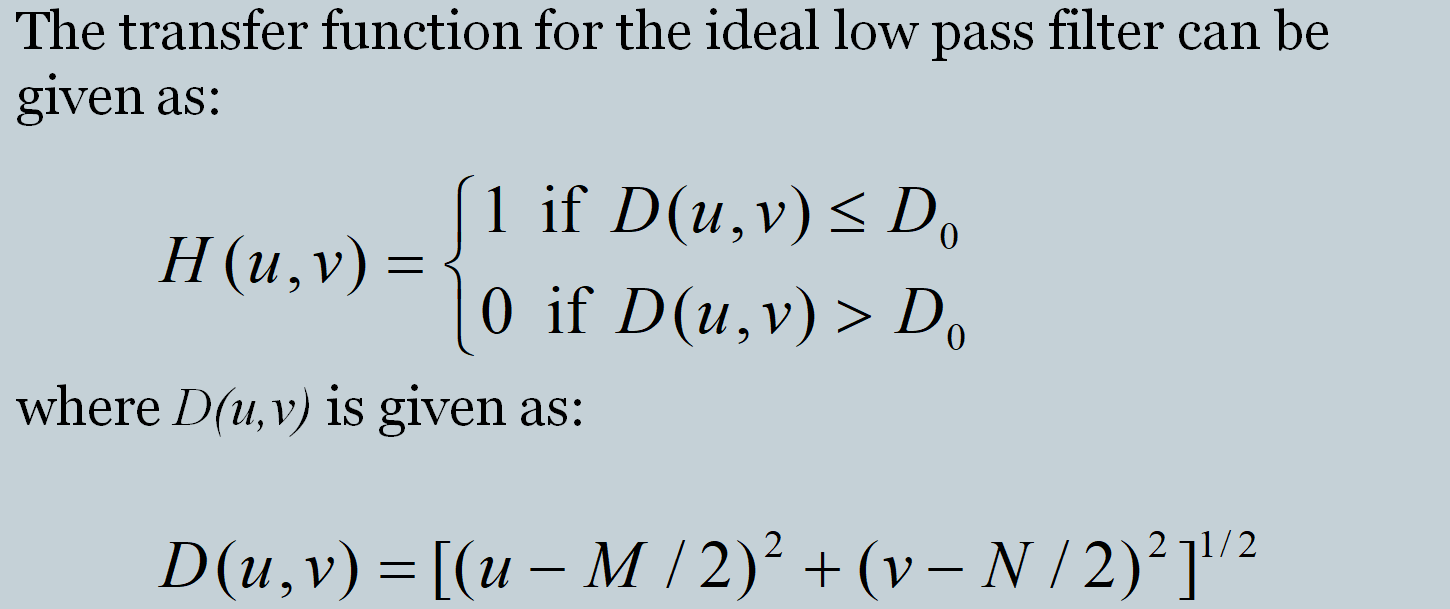
## - H(u,v) → filter transfer function
## - D(u,v) → distance from the center of frequency spectrum
## - D₀ → cutoff frequency
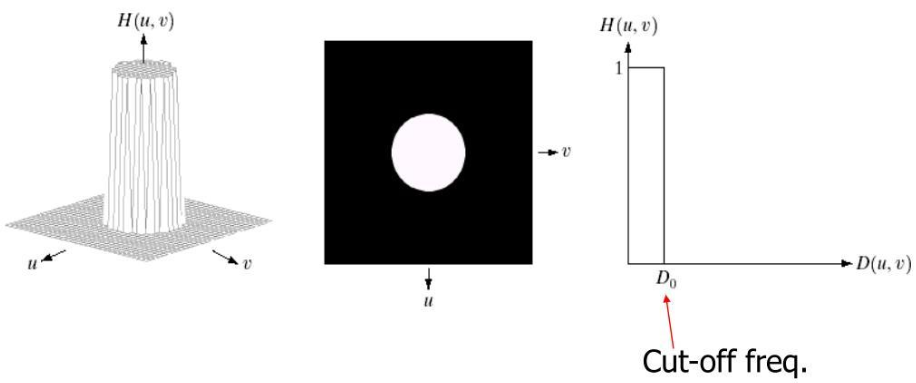

# Steps to apply
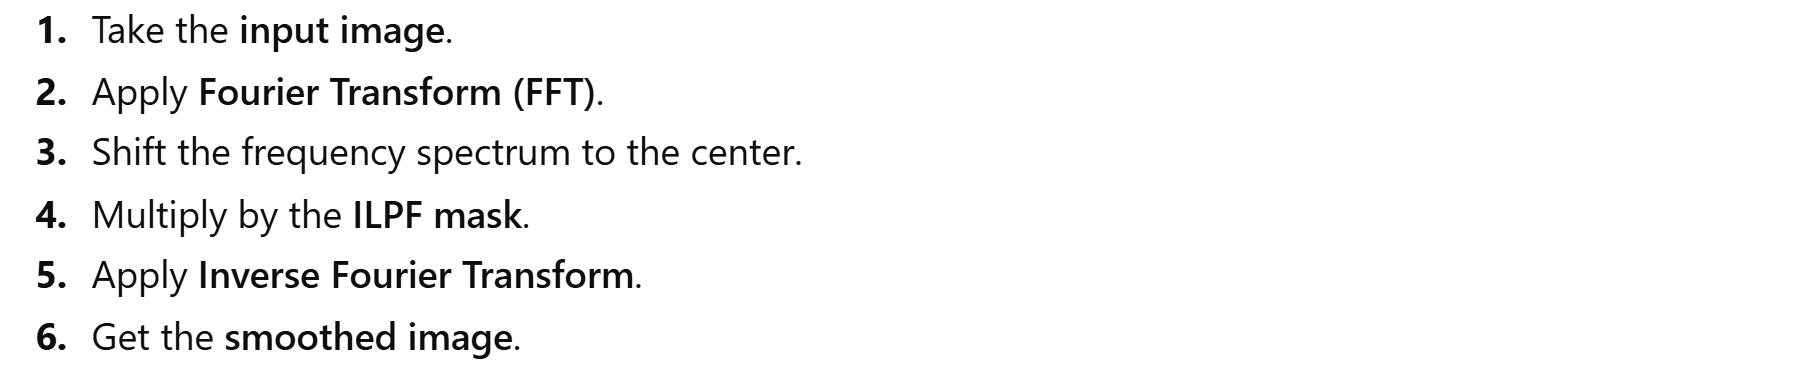

# Radius 15

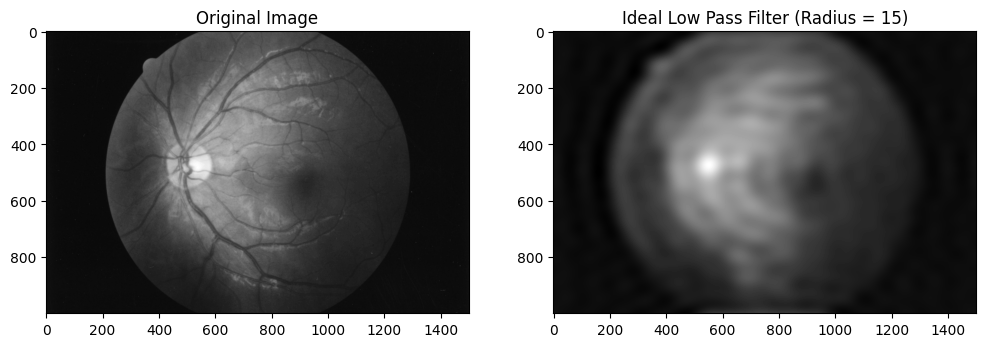

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image in grayscale
img = cv2.imread("image.jpg", 0)

# Fourier Transform
dft = np.fft.fft2(img)
dft_shift = np.fft.fftshift(dft)

# Image size
rows, cols = img.shape
crow, ccol = rows//2 , cols//2

# Create Ideal Low Pass Filter mask
D0 = 15   # cutoff frequency
mask = np.zeros((rows, cols), np.uint8)

for u in range(rows):
    for v in range(cols):
        D = np.sqrt((u - crow)**2 + (v - ccol)**2)
        if D <= D0:
            mask[u,v] = 1
        else:
            mask[u,v] = 0

# Apply mask
filtered = dft_shift * mask

# Inverse Fourier Transform
f_ishift = np.fft.ifftshift(filtered)
img_back = np.fft.ifft2(f_ishift)
img_back = np.abs(img_back)

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(121), plt.imshow(img, cmap='gray')
plt.title('Original Image')

plt.subplot(122), plt.imshow(img_back, cmap='gray')
plt.title('Ideal Low Pass Filter (Radius = 15)')

plt.show()

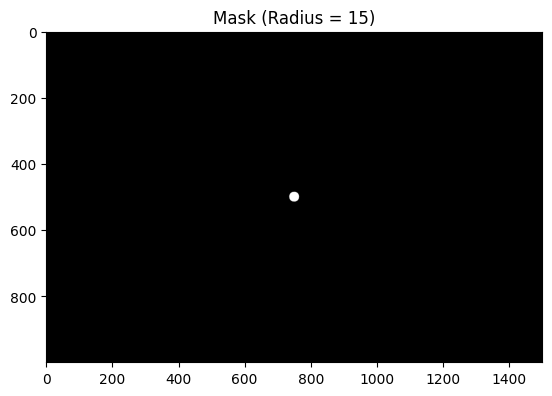

In [2]:
plt.imshow(mask, cmap='gray')
plt.title(f"Mask (Radius = {D0})")
plt.show()

# Radius 30

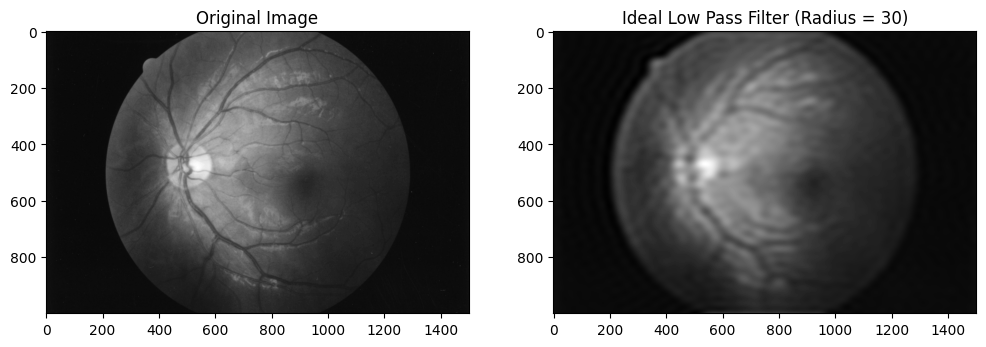

In [3]:
# Read image in grayscale
img = cv2.imread("image.jpg", 0)

# Fourier Transform
dft = np.fft.fft2(img)
dft_shift = np.fft.fftshift(dft)

# Image size
rows, cols = img.shape
crow, ccol = rows//2 , cols//2

# Create Ideal Low Pass Filter mask
D0 = 30   # cutoff frequency
mask = np.zeros((rows, cols), np.uint8)

for u in range(rows):
    for v in range(cols):
        D = np.sqrt((u - crow)**2 + (v - ccol)**2)
        if D <= D0:
            mask[u,v] = 1
        else:
            mask[u,v] = 0

# Apply mask
filtered = dft_shift * mask

# Inverse Fourier Transform
f_ishift = np.fft.ifftshift(filtered)
img_back = np.fft.ifft2(f_ishift)
img_back = np.abs(img_back)

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(121), plt.imshow(img, cmap='gray')
plt.title('Original Image')

plt.subplot(122), plt.imshow(img_back, cmap='gray')
plt.title('Ideal Low Pass Filter (Radius = 30)')

plt.show()

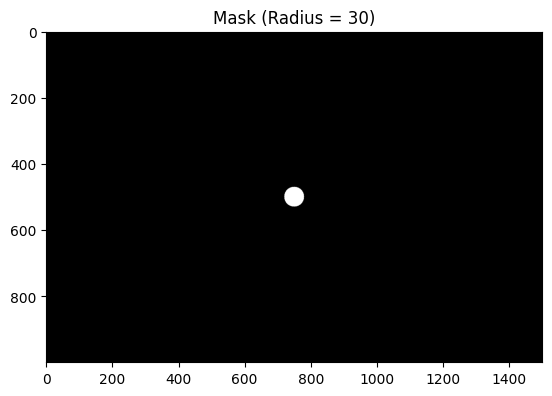

In [4]:
plt.imshow(mask, cmap='gray')
plt.title(f"Mask (Radius = {D0})")
plt.show()

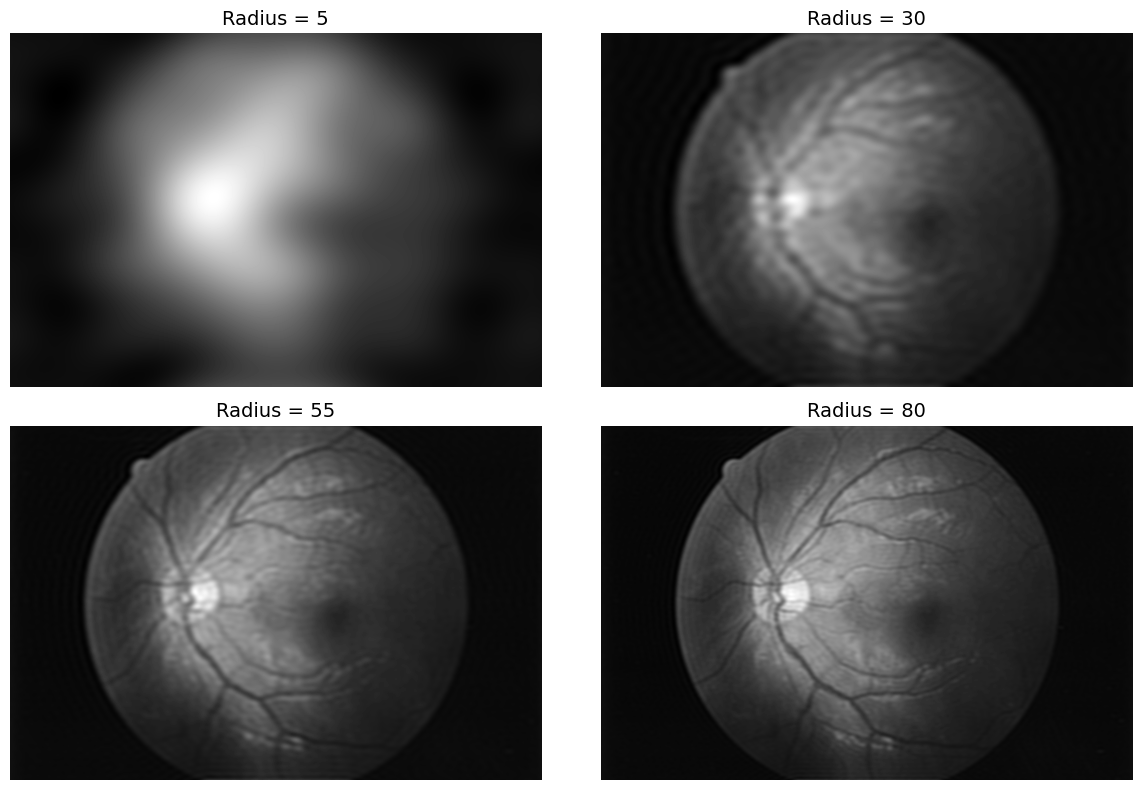

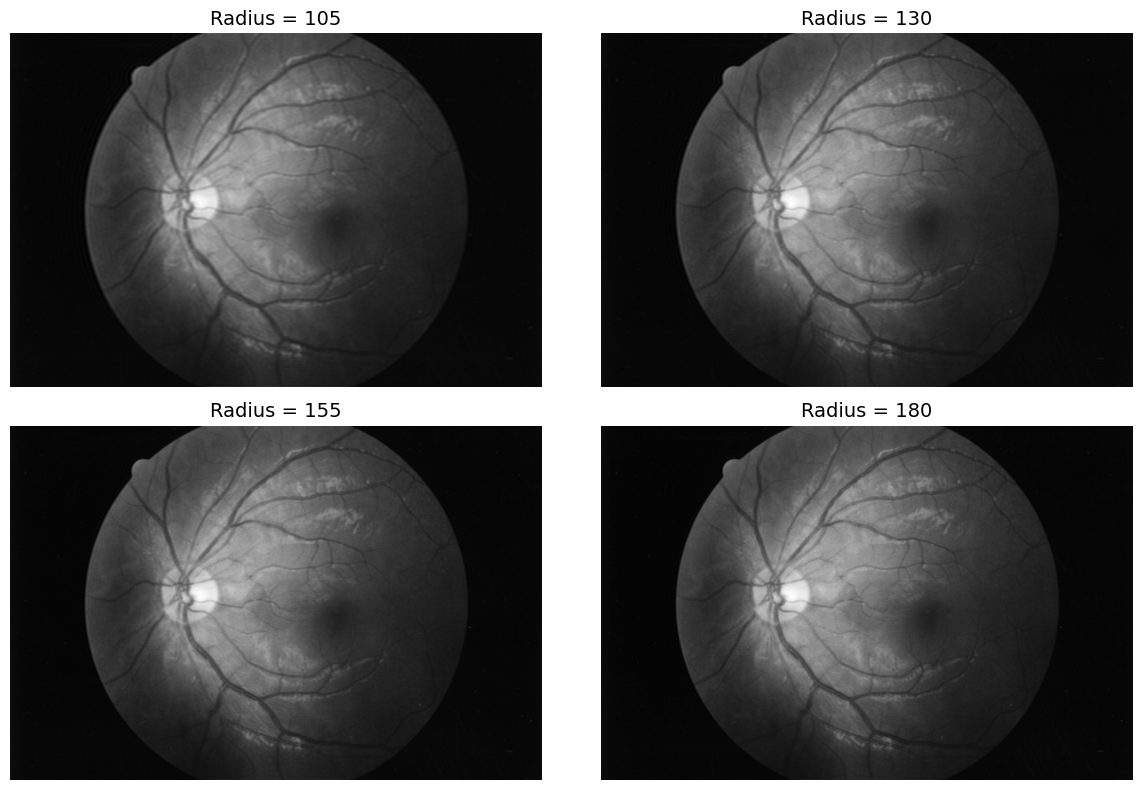

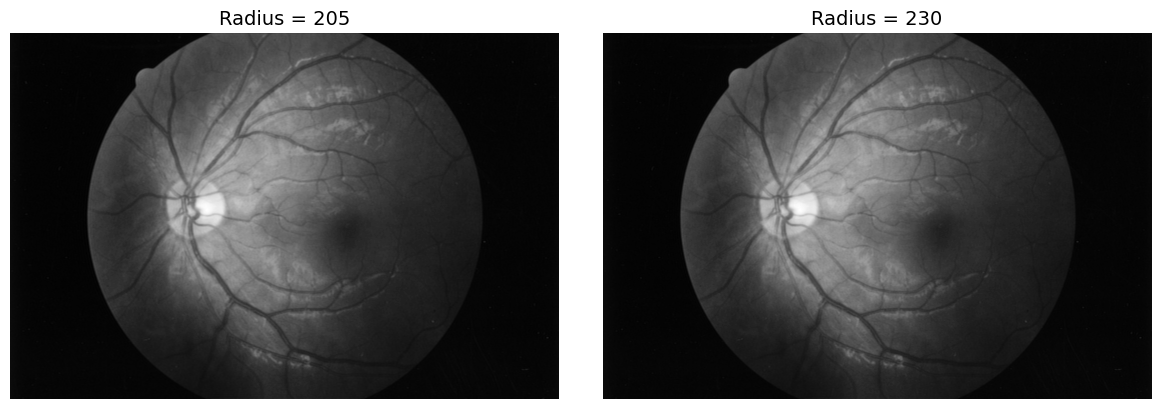

In [5]:
img = cv2.imread("image.jpg", 0)

dft = np.fft.fft2(img)
dft_shift = np.fft.fftshift(dft)

rows, cols = img.shape
crow, ccol = rows//2, cols//2

radii = list(range(5, 231, 25))

batch_size = 4

for i in range(0, len(radii), batch_size):
    plt.figure(figsize=(12, 8)) 
    
    batch = radii[i:i+batch_size]
    
    for j, D0 in enumerate(batch):
        x, y = np.ogrid[:rows, :cols]
        mask = ((x - crow)**2 + (y - ccol)**2 <= D0**2)

        filtered = dft_shift * mask
        img_back = np.fft.ifft2(np.fft.ifftshift(filtered))
        img_back = np.abs(img_back)

        plt.subplot(2, 2, j+1)
        plt.imshow(img_back, cmap='gray')
        plt.title(f'Radius = {D0}', fontsize=14)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Advantages
## - Simple concept
## - Removes high-frequency noise
## - Good for basic smoothing

# Disadvantages
## Produces ringing effect (Gibbs phenomenon) around edges
## Not practical for many real applications
## Better alternatives exist (Butterworth, Gaussian filters)